In [1]:
%matplotlib widget

In [2]:
import time

In [3]:
import torch.optim as optim
import torch

In [4]:
from chromatin3d.data.hic_loader import split
from chromatin3d.models.predictor import RousePINN
from chromatin3d.training.train import train
from chromatin3d.utils.misc import prettify_duration

In [5]:
train_loader, valid_loader = split("../data/ENCFF216QQM/ENCFF216QQM_chr1_5kbp/")

In [6]:
model = RousePINN(576)
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load("model.pth", map_location=device))

In [7]:
[i for i in model.parameters()]

[Parameter containing:
 tensor([[-9.4609e-04, -5.8508e-04, -1.3248e-03,  ...,  1.5362e-03,
          -1.2975e-03, -1.6324e-03],
         [ 3.0228e-04,  1.1459e-04,  1.4819e-03,  ..., -2.7071e-04,
           3.7147e-04,  1.0718e-03],
         [ 1.4100e-03, -4.7910e-04,  5.1143e-04,  ..., -6.2083e-04,
           7.6511e-04, -1.1512e-03],
         ...,
         [ 2.1771e-04, -2.2219e-04,  1.3156e-04,  ..., -8.8433e-04,
           1.2908e-04,  5.0038e-04],
         [ 1.7342e-03, -6.6737e-05, -2.4829e-04,  ...,  1.7992e-04,
          -8.2343e-05, -5.5881e-04],
         [ 9.7373e-04,  1.5484e-03, -2.5608e-04,  ..., -2.4440e-04,
           1.6070e-03,  7.7482e-04]], requires_grad=True),
 Parameter containing:
 tensor([-6.5475e-04,  1.5330e-03,  2.8822e-04,  5.3510e-04, -1.5596e-03,
          7.0499e-04,  3.2276e-04,  5.8273e-04,  5.4309e-04, -1.2813e-03,
          4.6416e-04,  1.0357e-03,  6.0521e-04,  1.9644e-05, -6.9616e-04,
         -4.2960e-05, -9.0154e-04, -3.9636e-05,  7.7500e-05, -1.51

In [8]:
# start = time.time()
# losses, metrics = train(model, optimizer, train_loader, valid_loader, 100, 10)
# end = time.time()

100%|██████████| 100/100 [9:03:23<00:00, 326.04s/it] 


In [9]:
# print(prettify_duration(end - start))

0d 9h 3m 24s


In [10]:
# losses

,data_losses,loops_losses,rouse_losses,smoothness_losses,total_losses
0,5562.559518,0.0,0.242709,1.905470,54.891179
1,5307.962193,0.0,0.858981,1.541883,52.937109
2,4840.472534,0.0,0.357587,1.441479,47.866211
3,4654.795433,0.0,0.190894,1.339354,45.871675
4,4507.653333,0.0,0.250800,1.213598,44.469701
...,...,...,...,...,...
95,3512.174031,0.0,0.658205,0.166559,34.948496
96,3510.252843,0.0,0.638611,0.172033,34.911693
97,3549.521870,0.0,0.579402,0.162084,35.235182
98,3549.391159,0.0,0.726698,0.182011,35.381535


In [11]:
# metrics

,heatmap_correlation_metrics,linker_length_mean_metrics,linker_length_std_metrics,persistence_length_metrics
0,0.218772,1.297662,0.842118,-389.365245
1,0.349811,1.091032,0.709368,-456.774668
2,0.393212,0.939554,0.448051,-396.131948
3,0.411696,0.941732,0.431327,-527.023773
4,0.424007,0.984452,0.339640,-574.720317
...,...,...,...,...
95,0.411421,0.953016,0.128663,-782.417684
96,0.411213,1.040345,0.145391,-817.490560
97,0.409916,0.928424,0.172834,-1010.248942
98,0.413932,0.965724,0.152236,-737.452901


In [12]:
# [i for i in model.parameters()]

[Parameter containing:
 tensor([[ 0.0291,  0.0294,  0.0287,  ...,  0.0316,  0.0287,  0.0284],
         [-0.0297, -0.0299, -0.0285,  ..., -0.0303,  0.0304, -0.0290],
         [-0.0286, -0.0305, -0.0295,  ..., -0.0306, -0.0293, -0.0312],
         ...,
         [ 0.0302,  0.0298,  0.0302,  ...,  0.0291,  0.0302,  0.0305],
         [ 0.0318,  0.0300,  0.0298,  ...,  0.0302,  0.0299,  0.0295],
         [ 0.0309,  0.0312,  0.0286,  ...,  0.0289,  0.0313,  0.0308]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0294, -0.0285, -0.0297, -0.0295,  0.0285,  0.0307,  0.0303, -0.0203,
         -0.0295, -0.0313,  0.0164,  0.0311,  0.0191,  0.0330, -0.0307, -0.0300,
          0.0291, -0.0300, -0.0299, -0.0315, -0.0299, -0.0315, -0.0308,  0.0283,
          0.0288,  0.0306,  0.0302, -0.0283,  0.0300,  0.0298, -0.0314,  0.0287,
         -0.0292,  0.0340,  0.0234, -0.0312, -0.0302, -0.0300,  0.0283,  0.0064,
         -0.0316, -0.0306, -0.0316,  0.0291,  0.0155, -0.0314, -0.0313,  0.0310

In [13]:
import torch
import matplotlib.pyplot as plt

In [14]:
for batch in train_loader:
    break

In [15]:
outputs = model(batch)

In [16]:
outputs.shape

torch.Size([10, 576, 3])

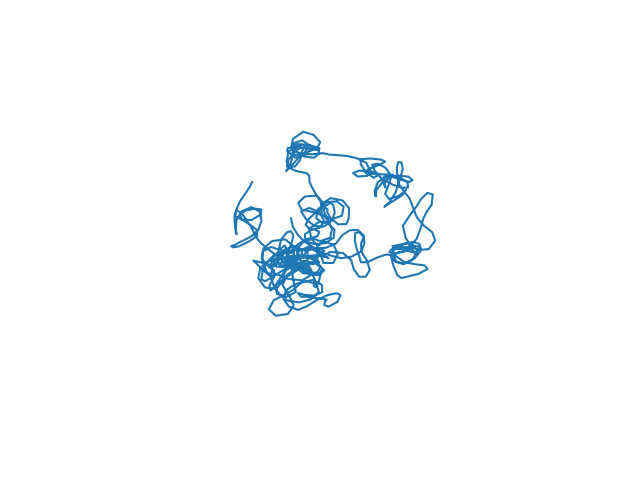

In [17]:
with torch.no_grad():
    fig = plt.figure()

    ax = fig.add_subplot(projection="3d")

    ax.plot(outputs[0, :, 0], outputs[0, :, 1], outputs[0, :, 2])

    ax.set_axis_off()

    plt.show()

In [19]:
# torch.save(model.state_dict(), "model.pth")